
# Fig. 5d — Active-regulon query cross-attention vs external CollecTRI targets

**Question:** when the Regulon Decoder queries the most active TF programs in a held-out VAL cell, does its final-layer cross-attention preferentially retrieve encoder genes that are independently supported as TF targets by CollecTRI?

Pipeline:

`VAL active_regulon_ids + active_auc → Top-3 active TFs → Regulon Decoder query prefix → query-TF→encoder-gene cross-attention → CollecTRI targets vs expression/detection-matched non-targets`

Important:
- VAL is a held-out validation partition, not an independent test set.
- CollecTRI is used only as the external target reference.
- Training pySCENIC targets are **not** used as positives; they are only excluded from the negative pool.
- Query attention is taken only at the TF query-token positions.
- The decoder input stops at `<startofanswer>`; because the Regulon Decoder is causal, query-token attention cannot see answer/target tokens.


In [1]:

from pathlib import Path

# ================= USER PATHS =================
CODE_DIR = Path("/root/autodl-tmp/ExpertCoder/ExpertCoder_Separate_decoder_activate_regulon")
STAGE2_YAML = Path("/root/autodl-tmp/ExpertCoder/ExpertCoder_Separate_decoder_activate_regulon/geosketch_50.yaml")
SCKODE_CKPT = Path("/root/autodl-tmp/pt/geosketch_50.pt")
VAL_MDS = Path("/root/autodl-tmp/geosketch_50/val")
TRAIN_REGULON_JSON = Path("/root/autodl-tmp/vocab/regulon_targets_importance_sorted.json")
COLLECTRI_CSV = Path("/root/autodl-tmp/fig5-1/collectri/collectri_human_no_complexes.csv")
OUT_DIR = Path("/root/autodl-tmp/fig5-1/geosketch_50_fig5d")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ================= ANALYSIS =================
TOP_ACTIVE_REGULONS_PER_CELL = 3
MAX_ANALYSIS_CELLS = None     # debug: 500; formal analysis: None

BATCH_SIZE = 32
MIN_COLLECTRI_TARGETS_PER_TF = 5
MIN_MATCHABLE_EXTERNAL_TARGETS_PER_CELL_TF = 3
MIN_EVALUABLE_CELLS_PER_TF = 10

MATCH_EXPR_N_BINS = 5
MATCH_DETECTION_N_BINS = 5
MATCH_REPEATS = 20
ALLOW_BACKGROUND_REPLACEMENT = True

SAVE_GENE_LEVEL = True
FORCE_RESCAN_VAL = False
FORCE_RERUN_ATTENTION = False
SEED = 2026

ACTIVE_REGULON_FIELD = "active_regulon_ids"
ACTIVE_AUC_FIELD = "active_auc"
CELL_ID_FIELD = "cell_id"
CELL_TYPE_FIELD = "cell_type"
GENES_FIELD = "genes"
EXPRESSIONS_FIELD = "expressions"

CANONICAL_TFS = [
    "TBX21",
    "PAX5",
    "EBF1",
    "SPI1",
    "IRF8",
    "EOMES"
]


In [2]:

import sys, json, gc, random, zlib, warnings
from collections import defaultdict
from contextlib import nullcontext

import numpy as np
import pandas as pd
import torch, yaml
from tqdm.auto import tqdm
from scipy.stats import rankdata, wilcoxon
from sklearn.metrics import roc_auc_score
from streaming import StreamingDataset

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

CODE_DIR = CODE_DIR.expanduser().resolve()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from tokenizer import GlobalGeneTextTokenizer
from data import left_binning, sample_or_truncate, load_regulon_target_lookup
from model import TahoeStage2MixedModel

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

def crc(s): return int(zlib.crc32(str(s).encode()) & 0xffffffff)
def clean(x): return " ".join(str(x).strip().split())

try:
    fm.findfont("Arial", fallback_to_default=False)
    family = "Arial"
except Exception:
    family = "sans-serif"
mpl.rcParams.update({"font.family": family, "axes.unicode_minus": False,
                     "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none"})


/root/miniconda3/envs/cllm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: cuda
NVIDIA GeForce RTX 5090


In [3]:

# Load YAML / tokenizer / training regulons
with open(STAGE2_YAML, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

gv = cfg["global_vocab"]; dc = cfg["data"]; dec = cfg.get("decoder", {})
tokenizer = GlobalGeneTextTokenizer.from_files(
    text_tokenizer_path=gv["text_tokenizer_path"],
    global_vocab_path=gv["global_vocab_path"],
    global_vocab_meta_path=gv["global_vocab_meta_path"],
    gene_table_path=gv["gene_table_path"],
    max_length=int(dec.get("max_decoder_length", dc.get("max_decoder_length", 1025))),
    use_fast=bool(gv.get("use_fast", True)),
    do_lower_case=bool(gv.get("do_lower_case", False)),
)

VOCAB_SIZE = int(tokenizer.vocab_size)
CLS_ID = int(tokenizer.cls_token_id); PAD_ID = int(tokenizer.pad_token_id); BOS_ID = int(tokenizer.bos_token_id)
MAX_ENCODER_LENGTH = int(dc.get("max_encoder_length", 2049))
MAX_DECODER_LENGTH = int(dec.get("max_decoder_length", dc.get("max_decoder_length", 1025)))
NUM_BINS = int(dc.get("num_bins", 51))
PAD_VALUE = float(dc.get("pad_value", -2.0)); CLS_VALUE = float(dc.get("cls_value", -1.0))
MASK_VALUE = float(dc.get("mask_value", -3.0))
KEEP_FIRST_N_TOKENS = int(dc.get("keep_first_n_tokens", 1))
N_REGULONS = int(dc.get("n_regulons", 530))

reg_lookup = load_regulon_target_lookup(TRAIN_REGULON_JSON, n_regulons=N_REGULONS)
for rid, r in reg_lookup.items():
    tfid = int(r["tf_token_id"])
    r["tf_gene"] = str(r.get("tf_gene", tokenizer.global_id_to_gene_symbol.get(tfid, str(tfid))))
    r["regulon_name"] = str(r.get("regulon_name", r["tf_gene"]))

print("vocab", VOCAB_SIZE, "n_regulons", N_REGULONS)


vocab 91714 n_regulons 530


In [4]:

# CollecTRI → global gene IDs
col = pd.read_csv(COLLECTRI_CSV)
need = {"source","target","weight","resources","references","sign_decision"}
assert need.issubset(col.columns), need - set(col.columns)

def map_symbol(x):
    gid = tokenizer.gene_name_to_global_id(str(x))
    return np.nan if gid is None else int(gid)

col["tf_token_id"] = col["source"].map(map_symbol)
col["target_token_id"] = col["target"].map(map_symbol)
mapped = col[col["tf_token_id"].notna() & col["target_token_id"].notna()].copy()
mapped["tf_token_id"] = mapped["tf_token_id"].astype(int)
mapped["target_token_id"] = mapped["target_token_id"].astype(int)
mapped = mapped[mapped["tf_token_id"] != mapped["target_token_id"]].drop_duplicates(["source","target"])

counts = mapped.groupby("source")["target_token_id"].nunique()
eligible = set(counts[counts >= MIN_COLLECTRI_TARGETS_PER_TF].index)
mapped = mapped[mapped["source"].isin(eligible)].copy()

collectri_targets = {tf:set(g["target_token_id"].astype(int)) for tf,g in mapped.groupby("source")}
collectri_symbol = {(str(r.source),int(r.target_token_id)):str(r.target)
                    for r in mapped.itertuples(index=False)}

print("raw:", col.shape, "mapped eligible edges:", len(mapped),
      "eligible TFs:", mapped["source"].nunique())
mapped.to_csv(OUT_DIR/"collectri_mapped_reference.csv", index=False)


raw: (41595, 8) mapped eligible edges: 40098 eligible TFs: 756


In [5]:

# Open VAL + preprocessing
val_ds = StreamingDataset(local=str(VAL_MDS), shuffle=False, batch_size=1, allow_unsafe_types=True)
print("VAL cells:", len(val_ds))
s0 = val_ds[0]
print(sorted(s0.keys()))

def map_gene(x):
    if hasattr(x, "item") and not isinstance(x,(str,bytes)):
        try: x = x.item()
        except: pass
    try:
        if isinstance(x,(int,np.integer)) or str(x).strip().isdigit():
            gid = int(x)
            if gid in tokenizer.global_id_to_token and tokenizer.global_id_is_gene(gid):
                return gid
    except: pass
    return tokenizer.gene_name_to_global_id(str(x))

def prepare_encoder_record(rec):
    gids, vals = [], []
    for g,v in zip(rec[GENES_FIELD], rec[EXPRESSIONS_FIELD]):
        gid = map_gene(g)
        if gid is not None:
            gids.append(int(gid)); vals.append(float(v))
    genes = torch.tensor([CLS_ID] + gids, dtype=torch.long)
    raw = torch.tensor([CLS_VALUE] + vals, dtype=torch.float)
    genes, raw = sample_or_truncate(
        genes, raw, MAX_ENCODER_LENGTH,
        keep_first_n_tokens=KEEP_FIRST_N_TOKENS,
        sampling=False, generator=None
    )
    binned = raw.clone()
    if len(binned) > KEEP_FIRST_N_TOKENS:
        binned[KEEP_FIRST_N_TOKENS:] = left_binning(
            binned[KEEP_FIRST_N_TOKENS:], NUM_BINS
        ).float()
    return {"gene_ids":genes, "raw":raw, "binned":binned}

def select_top3(rec):
    ids = np.asarray(rec[ACTIVE_REGULON_FIELD]).astype(int)
    auc = np.asarray(rec[ACTIVE_AUC_FIELD]).astype(float)
    assert len(ids) == len(auc)
    ok = np.isfinite(auc) & (ids>=0) & (ids<N_REGULONS)
    ids, auc = ids[ok], auc[ok]
    order = np.argsort(-auc, kind="mergesort")
    out, seen = [], set()
    for j in order:
        rid = int(ids[j]); r = reg_lookup[rid]; tfid = int(r["tf_token_id"])
        if tfid in seen: continue
        seen.add(tfid)
        out.append({"regulon_id":rid, "active_auc":float(auc[j]),
                    "tf_gene":str(r["tf_gene"]), "tf_token_id":tfid,
                    "regulon_name":str(r["regulon_name"])})
        if len(out) == TOP_ACTIVE_REGULONS_PER_CELL: break
    return out if len(out) == TOP_ACTIVE_REGULONS_PER_CELL else []

display(pd.DataFrame(select_top3(s0)))


VAL cells: 18849
['active_auc', 'active_regulon_ids', 'cell_id', 'cell_type', 'expressions', 'genes', 'natural_language_annotation']


,regulon_id,active_auc,tf_gene,tf_token_id,regulon_name
0,410,0.356940,TCF12,7925,TCF12(+)
1,372,0.289602,SOX6,3799,SOX6(+)
2,218,0.228385,LEF1,7739,LEF1(+)


In [6]:

# Scan VAL: selected cells + global detection frequency
index_path = OUT_DIR/"val_top3_index.csv"
det_path = OUT_DIR/"val_detection.csv"

if index_path.exists() and det_path.exists() and not FORCE_RESCAN_VAL:
    analysis_index = pd.read_csv(index_path)
    det_df = pd.read_csv(det_path)
else:
    det_count = np.zeros(VOCAB_SIZE, dtype=np.int64)
    n_det_cells = 0; rows = []
    for i in tqdm(range(len(val_ds)), desc="scan VAL"):
        rec = val_ds[i]
        enc = prepare_encoder_record(rec)
        body = enc["gene_ids"].numpy()[KEEP_FIRST_N_TOKENS:]
        if len(body): det_count[np.unique(body)] += 1
        n_det_cells += 1

        sel = select_top3(rec)
        if not sel: continue
        rows.append({
            "dataset_index":i, "cell_id":str(rec[CELL_ID_FIELD]),
            "cell_type":clean(rec.get(CELL_TYPE_FIELD,"")),
            "regulon_ids_json":json.dumps([x["regulon_id"] for x in sel]),
            "tf_genes_json":json.dumps([x["tf_gene"] for x in sel]),
            "active_auc_json":json.dumps([x["active_auc"] for x in sel]),
        })
        if MAX_ANALYSIS_CELLS is not None and len(rows) >= int(MAX_ANALYSIS_CELLS):
            warnings.warn("DEBUG mode: set MAX_ANALYSIS_CELLS=None and rescan for formal analysis.")
            break

    analysis_index = pd.DataFrame(rows)
    obs = np.where(det_count>0)[0]
    det_df = pd.DataFrame({
        "gene_token_id":obs,
        "detection_count":det_count[obs],
        "detection_frequency":det_count[obs]/max(n_det_cells,1)
    })
    analysis_index.to_csv(index_path,index=False)
    det_df.to_csv(det_path,index=False)

def pct_bins(values, n_bins):
    values=np.asarray(values,float)
    r=rankdata(values,method="average")
    return np.clip(np.floor(((r-0.5)/len(values))*n_bins).astype(int),0,n_bins-1)

det_df["detection_bin"] = pct_bins(det_df["detection_frequency"], MATCH_DETECTION_N_BINS)
det_bin = dict(zip(det_df["gene_token_id"].astype(int), det_df["detection_bin"].astype(int)))
det_freq = dict(zip(det_df["gene_token_id"].astype(int), det_df["detection_frequency"].astype(float)))
det_df.to_csv(det_path,index=False)

print("analysis cells:",len(analysis_index))
display(analysis_index.head())


analysis cells: 18849


,dataset_index,cell_id,cell_type,regulon_ids_json,tf_genes_json,active_auc_json
0,0,census_4d43082e-59cd-43ac-b77d-54d55519c881_587,oligodendrocyte,"[410, 372, 218]","[""TCF12"", ""SOX6"", ""LEF1""]","[0.35694000124931335, 0.28960201144218445, 0.2..."
1,1,census_44882825-0da1-4547-b721-2c6105d4a9d1_656,tonsil germinal center B cell,"[217, 224, 222]","[""KMT2A"", ""LYL1"", ""LUZP1""]","[0.2122880071401596, 0.16595099866390228, 0.16..."
2,2,census_b46237d1-19c6-4af2-9335-9854634bad16_13768,interstitial cell of Cajal,"[431, 353, 240]","[""TPI1"", ""SIX1"", ""MEIS2""]","[0.5973860025405884, 0.3199999928474426, 0.238..."
3,3,census_1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1_8402,malignant cell,"[431, 474, 299]","[""TPI1"", ""ZNF214"", ""PGAM2""]","[0.5708500146865845, 0.20816999673843384, 0.14..."
4,4,census_218acb0f-9f2f-4f76-b90b-15a4b7c7f629_11791,B cell,"[431, 464, 273]","[""TPI1"", ""ZNF133"", ""NKX2-8""]","[0.4150330126285553, 0.1691499948501587, 0.166..."


In [7]:

# Exact decoder query prefix + query positions
TASK_NAME_IDS = tokenizer.encode_task_name_to_global_ids("regulon")

def query_prefix(tf_ids):
    tf_ids=[int(x) for x in tf_ids]
    qids=tokenizer.encode_regulon_query_ids(tf_ids)
    target_prefix=[int(tokenizer.task_token_id)] + list(TASK_NAME_IDS) + list(qids) + [int(tokenizer.start_answer_token_id)]
    dec_ids=[BOS_ID] + target_prefix
    q_start_target=1+len(TASK_NAME_IDS)
    qpos=[1+q_start_target+2*j for j in range(len(tf_ids))]
    for p,t in zip(qpos,tf_ids):
        assert int(dec_ids[p]) == int(t)
    return dec_ids,qpos

sel0=select_top3(s0)
d0,p0=query_prefix([x["tf_token_id"] for x in sel0])
print(tokenizer.decode_debug(d0))
print("query positions:",p0)


<bos> <task> re ##gu ##lon <gene:TCF12> <gene_sep> <gene:SOX6> <gene_sep> <gene:LEF1> <startofanswer>
query positions: [5, 7, 9]


In [8]:

# Load Stage2 scKODE
mcfg=dict(cfg.get("model",{}))
for k in ["stage1_ckpt_path","freeze_encoder","freeze_embeddings","freeze_value_head",
          "gene_vocab_size","text_vocab_size","vocab_size"]:
    mcfg.pop(k,None)
mcfg["global_vocab_size"]=int(tokenizer.vocab_size)
mcfg["pad_token_id"]=int(tokenizer.pad_token_id)
mcfg["mask_value"]=MASK_VALUE
mcfg["max_decoder_length"]=MAX_DECODER_LENGTH

model=TahoeStage2MixedModel(**mcfg)
ck=torch.load(SCKODE_CKPT,map_location="cpu")
state=ck["model_state_dict"] if isinstance(ck,dict) and "model_state_dict" in ck else ck
if state and all(str(k).startswith("module.") for k in state):
    state={str(k)[7:]:v for k,v in state.items()}
missing,unexpected=model.load_state_dict(state,strict=False)
critical=("encoder","shared_token_embedding","value_encoder",
          "regulon_decoder","regulon_decoder_position_embedding","regulon_decoder_token_norm")
bad=[k for k in missing if k.startswith(critical)]
if bad: raise RuntimeError("critical missing:\n" + "\n".join(bad[:100]))
print("missing",len(missing),"unexpected",len(unexpected))
model.to(DEVICE).eval()
for p in model.parameters(): p.requires_grad_(False)


missing 0 unexpected 0


In [9]:

# Batch + matching helpers
def prepare_batch(records, selections):
    encs=[prepare_encoder_record(r) for r in records]
    decs=[]
    for sel in selections:
        d,q=query_prefix([x["tf_token_id"] for x in sel]); decs.append((d,q))
    me=max(len(x["gene_ids"]) for x in encs); md=max(len(x[0]) for x in decs); B=len(records)
    gids=torch.full((B,me),PAD_ID,dtype=torch.long)
    bins=torch.full((B,me),PAD_VALUE,dtype=torch.float)
    raw=torch.full((B,me),float("nan"),dtype=torch.float)
    epad=torch.ones((B,me),dtype=torch.bool)
    dids=torch.full((B,md),PAD_ID,dtype=torch.long)
    dmask=torch.zeros((B,md),dtype=torch.long)
    qpos=[]
    for i,(e,(d,q)) in enumerate(zip(encs,decs)):
        L=len(e["gene_ids"]); D=len(d)
        gids[i,:L]=e["gene_ids"]; bins[i,:L]=e["binned"]; raw[i,:L]=e["raw"]; epad[i,:L]=False
        dids[i,:D]=torch.tensor(d); dmask[i,:D]=1; qpos.append(q)
    return dict(gids=gids,bins=bins,raw=raw,epad=epad,dids=dids,dmask=dmask,qpos=qpos)

def attn_percentile(x):
    return rankdata(np.asarray(x,float),method="average")/len(x)

def eval_cell_tf(cell_id,cell_type,sel,gids,expr,attn):
    rid=int(sel["regulon_id"]); tf=str(sel["tf_gene"]); tfid=int(sel["tf_token_id"])
    ext=collectri_targets.get(tf)
    if not ext: return None,[]
    train=set(map(int,reg_lookup[rid]["target_token_ids"]))
    gids=np.asarray(gids,int); expr=np.asarray(expr,float); attn=np.asarray(attn,float)
    eb=pct_bins(expr,MATCH_EXPR_N_BINS)
    db=np.asarray([det_bin.get(int(g),-1) for g in gids],int)
    pos={int(g):i for i,g in enumerate(gids)}
    positives=[g for g in ext if g in pos and g!=tfid]
    if len(positives)<MIN_MATCHABLE_EXTERNAL_TARGETS_PER_CELL_TF: return None,[]

    excluded=set(ext)|train|{tfid}
    pools=defaultdict(list)
    for i,g in enumerate(gids):
        g=int(g)
        if g in excluded or db[i]<0: continue
        pools[(int(eb[i]),int(db[i]))].append(g)

    trs=[]
    for g in positives:
        i=pos[g]; key=(int(eb[i]),int(db[i])); pool=pools.get(key,[])
        if not pool: continue
        trs.append(dict(gid=g, gene=collectri_symbol.get((tf,g),tokenizer.global_id_to_gene_symbol.get(g,str(g))),
                        score=float(attn[i]), expr=float(expr[i]), key=key, pool=list(pool),
                        also_train=(g in train)))
    if len(trs)<MIN_MATCHABLE_EXTERNAL_TARGETS_PER_CELL_TF: return None,[]

    rng=np.random.default_rng(SEED+crc(f"{cell_id}|{tf}"))
    n=len(trs); bg=np.full((n,MATCH_REPEATS),np.nan); aucs=[]
    bybin=defaultdict(list)
    for i,r in enumerate(trs): bybin[r["key"]].append(i)

    for rep in range(MATCH_REPEATS):
        repbg=np.full(n,np.nan)
        for key,inds in bybin.items():
            union=sorted(set().union(*[set(trs[i]["pool"]) for i in inds]))
            if not union: continue
            replace=len(union)<len(inds)
            if replace and not ALLOW_BACKGROUND_REPLACEMENT: continue
            chosen=rng.choice(np.asarray(union,int),size=len(inds),replace=replace)
            for jj,ti in enumerate(inds):
                gg=int(chosen[jj])
                if gg not in trs[ti]["pool"]:
                    gg=int(rng.choice(np.asarray(trs[ti]["pool"],int)))
                repbg[ti]=attn[pos[gg]]; bg[ti,rep]=repbg[ti]
        valid=np.isfinite(repbg)
        if valid.sum()>=MIN_MATCHABLE_EXTERNAL_TARGETS_PER_CELL_TF:
            y=np.r_[np.ones(valid.sum()),np.zeros(valid.sum())]
            s=np.r_[np.asarray([r["score"] for r in trs])[valid],repbg[valid]]
            aucs.append(float(roc_auc_score(y,s)))

    bgmean=np.nanmean(bg,axis=1); valid=np.isfinite(bgmean)
    if valid.sum()<MIN_MATCHABLE_EXTERNAL_TARGETS_PER_CELL_TF: return None,[]
    ts=np.asarray([r["score"] for r in trs],float)
    bgmed=[np.median(bg[valid,r][np.isfinite(bg[valid,r])]) for r in range(MATCH_REPEATS)
           if np.isfinite(bg[valid,r]).any()]
    if not bgmed: return None,[]
    tmed=float(np.median(ts[valid])); bscore=float(np.mean(bgmed))
    summary=dict(cell_id=str(cell_id),cell_type=str(cell_type),regulon_id=rid,tf_gene=tf,tf_token_id=tfid,
                 active_auc=float(sel["active_auc"]),n_matchable_external_targets=int(valid.sum()),
                 target_attention=tmed,background_attention=bscore,delta_attention=tmed-bscore,
                 matched_auroc=float(np.mean(aucs)) if aucs else np.nan,
                 fraction_external_targets_also_training_targets=float(np.mean([trs[i]["also_train"] for i in np.where(valid)[0]])))
    gene_rows=[]
    for i,r in enumerate(trs):
        if not valid[i]: continue
        gene_rows.append(dict(cell_id=str(cell_id),cell_type=str(cell_type),regulon_id=rid,tf_gene=tf,
                              active_auc=float(sel["active_auc"]),target_gene=r["gene"],target_token_id=r["gid"],
                              target_attention_percentile=r["score"],matched_background_attention_mean=float(bgmean[i]),
                              delta_attention=float(r["score"]-bgmean[i]),target_raw_expression=r["expr"],
                              target_detection_frequency=float(det_freq.get(r["gid"],np.nan)),
                              expression_bin=r["key"][0],detection_bin=r["key"][1],
                              also_training_target=bool(r["also_train"])))
    return summary,gene_rows


In [10]:

# Main inference
summary_path=OUT_DIR/"cell_active_tf_attention_summary.csv"
gene_path=OUT_DIR/"external_target_gene_level.parquet"

if summary_path.exists() and not FORCE_RERUN_ATTENTION:
    cell_tf_df=pd.read_csv(summary_path)
    gene_df=pd.read_parquet(gene_path) if SAVE_GENE_LEVEL and gene_path.exists() else pd.DataFrame()
else:
    sums=[]; genes_out=[]
    for st in tqdm(range(0,len(analysis_index),BATCH_SIZE),desc="cross-attention"):
        block=analysis_index.iloc[st:st+BATCH_SIZE]
        records=[]; sels=[]
        for row in block.itertuples(index=False):
            rec=val_ds[int(row.dataset_index)]; sel=select_top3(rec)
            if sel: records.append(rec); sels.append(sel)
        if not records: continue
        b=prepare_batch(records,sels)
        gd=b["gids"].to(DEVICE); bv=b["bins"].to(DEVICE); em=b["epad"].to(DEVICE)
        dd=b["dids"].to(DEVICE); dm=b["dmask"].to(DEVICE)
        with torch.inference_mode():
            enc,_=model.encode(encoder_input_gene_ids=gd,encoder_input_values=bv,
                               encoder_key_padding_mask=em,return_last_attn=False)
            _,ca=model.decode_regulon(decoder_input_ids=dd,encoder_outputs=enc,
                                      decoder_attention_mask=dm,encoder_key_padding_mask=em,
                                      return_last_cross_attn=True)
        ca=ca.detach().float().cpu().numpy()
        gcpu=b["gids"].numpy(); rcpu=b["raw"].numpy(); mcpu=b["epad"].numpy()

        for bi,(rec,sel) in enumerate(zip(records,sels)):
            valid=~mcpu[bi]; ga=gcpu[bi][valid]; ra=rcpu[bi][valid]
            keep=np.asarray([tokenizer.global_id_is_gene(int(g)) for g in ga],bool)
            encpos=np.where(valid)[0][keep]; gids=ga[keep].astype(int); expr=ra[keep].astype(float)
            for qi,sx in enumerate(sel):
                qp=int(b["qpos"][bi][qi])
                assert int(b["dids"][bi,qp])==int(sx["tf_token_id"])
                scores=ca[bi, :, qp, :][:, encpos].mean(axis=0)
                pct=attn_percentile(scores)
                sm,gr=eval_cell_tf(rec[CELL_ID_FIELD],clean(rec.get(CELL_TYPE_FIELD,"")),sx,gids,expr,pct)
                if sm is not None:
                    sums.append(sm)
                    if SAVE_GENE_LEVEL: genes_out.extend(gr)
        del gd,bv,em,dd,dm,enc,ca
        gc.collect()
        if DEVICE.type=="cuda": torch.cuda.empty_cache()

    cell_tf_df=pd.DataFrame(sums); cell_tf_df.to_csv(summary_path,index=False)
    gene_df=pd.DataFrame(genes_out)
    if SAVE_GENE_LEVEL: gene_df.to_parquet(gene_path,index=False)

print("cell×TF rows:",len(cell_tf_df),"TFs:",cell_tf_df["tf_gene"].nunique() if len(cell_tf_df) else 0)
display(cell_tf_df.head())


cross-attention: 100%|██████████| 590/590 [14:52<00:00,  1.51s/it]


cell×TF rows: 14428 TFs: 83


,cell_id,cell_type,regulon_id,tf_gene,tf_token_id,active_auc,n_matchable_external_targets,target_attention,background_attention,delta_attention,matched_auroc,fraction_external_targets_also_training_targets
0,census_4d43082e-59cd-43ac-b77d-54d55519c881_587,oligodendrocyte,410,TCF12,7925,0.356940,3,0.961171,0.616320,0.344851,0.777778,0.0
1,census_4d43082e-59cd-43ac-b77d-54d55519c881_587,oligodendrocyte,218,LEF1,7739,0.228385,7,0.791784,0.426927,0.364856,0.734694,0.0
2,census_489eaa11-c119-4a5f-b44b-81e33c80c0ef_423,neuron,427,THRB,9356,0.392019,6,0.863525,0.568640,0.294885,0.669444,0.0
3,census_576f193c-75d0-4a11-bd25-8676587e6dc2_3162,dendritic cell,319,PPARA,16342,0.233115,29,0.831868,0.540742,0.291126,0.621344,0.0
4,census_576f193c-75d0-4a11-bd25-8676587e6dc2_3162,dendritic cell,384,SPIC,11786,0.182135,3,0.273077,0.711813,-0.438736,0.188889,0.0


In [11]:

# TF-level aggregation + main statistics
if len(cell_tf_df)==0:
    raise RuntimeError("No evaluable cell×TF rows. Check coverage/matching thresholds.")

rows=[]
for tf,g in cell_tf_df.groupby("tf_gene"):
    n=g["cell_id"].nunique()
    if n<MIN_EVALUABLE_CELLS_PER_TF: continue
    ta=float(g["target_attention"].median()); ba=float(g["background_attention"].median())
    rows.append(dict(tf_gene=tf,n_evaluable_cells=int(n),
                     target_attention=ta,background_attention=ba,delta_attention=ta-ba,
                     median_cell_delta_attention=float(g["delta_attention"].median()),
                     median_auroc=float(g["matched_auroc"].dropna().median()) if g["matched_auroc"].notna().any() else np.nan,
                     median_active_auc=float(g["active_auc"].median()),
                     median_matchable_external_targets=float(g["n_matchable_external_targets"].median()),
                     median_external_training_target_overlap=float(g["fraction_external_targets_also_training_targets"].median())))
tf_df=pd.DataFrame(rows)
if len(tf_df)==0: raise RuntimeError("No TF passed MIN_EVALUABLE_CELLS_PER_TF.")

target=tf_df["target_attention"].to_numpy(float); bg=tf_df["background_attention"].to_numpy(float)
delta=target-bg
w,p=wilcoxon(target,bg,alternative="two-sided") if not np.allclose(delta,0) else (0.0,1.0)
auc=tf_df["median_auroc"].dropna().to_numpy(float)
wa,pa=wilcoxon(auc,np.full(len(auc),0.5),alternative="two-sided") if len(auc) and not np.allclose(auc-0.5,0) else (0.0,1.0)

stats=pd.DataFrame([dict(
    n_tfs=len(tf_df),
    median_target_attention=float(np.median(target)),
    median_background_attention=float(np.median(bg)),
    median_paired_delta_attention=float(np.median(delta)),
    n_positive_tfs=int((delta>0).sum()),
    fraction_positive_tfs=float((delta>0).mean()),
    wilcoxon_attention_statistic=float(w),wilcoxon_attention_p=float(p),
    n_tfs_with_auroc=len(auc),median_auroc=float(np.median(auc)) if len(auc) else np.nan,
    n_tfs_auroc_above_0_5=int((auc>0.5).sum()) if len(auc) else 0,
    fraction_tfs_auroc_above_0_5=float((auc>0.5).mean()) if len(auc) else np.nan,
    wilcoxon_auroc_vs_0_5_statistic=float(wa),wilcoxon_auroc_vs_0_5_p=float(pa)
)])
tf_df.to_csv(OUT_DIR/"tf_level_attention_summary.csv",index=False)
stats.to_csv(OUT_DIR/"main_statistics.csv",index=False)

display(stats)
display(tf_df.sort_values("delta_attention",ascending=False).head(30))


,n_tfs,median_target_attention,median_background_attention,median_paired_delta_attention,n_positive_tfs,fraction_positive_tfs,wilcoxon_attention_statistic,wilcoxon_attention_p,n_tfs_with_auroc,median_auroc,n_tfs_auroc_above_0_5,fraction_tfs_auroc_above_0_5,wilcoxon_auroc_vs_0_5_statistic,wilcoxon_auroc_vs_0_5_p
0,45,0.595642,0.514581,0.069332,32,0.711111,350.0,0.058944,45,0.544898,31,0.688889,340.0,0.044988


,tf_gene,n_evaluable_cells,target_attention,background_attention,delta_attention,median_cell_delta_attention,median_auroc,median_active_auc,median_matchable_external_targets,median_external_training_target_overlap
19,NFIX,34,0.744652,0.479918,0.264735,0.229845,0.642875,0.230800,3.0,0.000000
34,SOX6,70,0.757632,0.515869,0.241762,0.239929,0.716667,0.399494,3.0,0.000000
9,HEY1,135,0.698242,0.479065,0.219177,0.238719,0.705556,0.216471,3.0,0.000000
24,POU4F2,21,0.684496,0.503516,0.180980,0.194055,0.631250,0.216993,6.0,0.166667
39,TBX21,23,0.749629,0.570663,0.178966,0.133234,0.597222,0.152126,5.0,0.272727
2,BHLHE41,50,0.687040,0.513224,0.173817,0.197974,0.654687,0.212325,3.0,0.000000
12,KLF1,71,0.791667,0.619782,0.171884,0.116565,0.597656,0.229085,7.0,0.000000
3,CREB5,29,0.670961,0.508476,0.162485,0.140332,0.572222,0.312418,3.0,0.000000
17,LYL1,235,0.696289,0.535474,0.160815,0.147607,0.647222,0.187302,4.0,0.000000
13,KLF2,45,0.684910,0.528112,0.156798,0.114470,0.634722,0.154623,5.0,0.250000


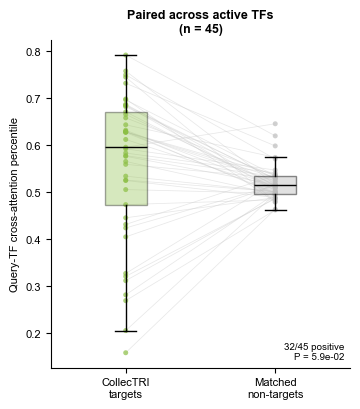

In [12]:

# Main paired figure
GREEN="#8CBF45"; GREY="#BDBDBD"
fig,ax=plt.subplots(figsize=(3.7,4.2))
for _,r in tf_df.iterrows():
    ax.plot([0,1],[r.target_attention,r.background_attention],color="0.80",lw=.55,alpha=.45,zorder=1)
ax.scatter(np.zeros(len(tf_df)),tf_df.target_attention,s=13,color=GREEN,alpha=.7,edgecolor="none",zorder=2)
ax.scatter(np.ones(len(tf_df)),tf_df.background_attention,s=13,color=GREY,alpha=.7,edgecolor="none",zorder=2)
bp=ax.boxplot([tf_df.target_attention,tf_df.background_attention],positions=[0,1],widths=.28,
              patch_artist=True,showfliers=False,medianprops={"color":"black","linewidth":1})
bp["boxes"][0].set_facecolor(GREEN); bp["boxes"][0].set_alpha(.35)
bp["boxes"][1].set_facecolor(GREY); bp["boxes"][1].set_alpha(.45)
ax.set_xticks([0,1]); ax.set_xticklabels(["CollecTRI\ntargets","Matched\nnon-targets"],fontsize=8)
ax.set_ylabel("Query-TF cross-attention percentile",fontsize=8)
ax.set_title(f"Paired across active TFs\n(n = {len(tf_df)})",fontsize=9,fontweight="bold")
ax.text(.98,.02,f"{int((delta>0).sum())}/{len(tf_df)} positive\nP = {p:.1e}",
        transform=ax.transAxes,ha="right",va="bottom",fontsize=7)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.tick_params(axis="y",labelsize=8)
fig.tight_layout()
for ext in ["pdf","svg","png"]:
    kw={"bbox_inches":"tight","facecolor":"white"}
    if ext=="png": kw["dpi"]=600
    fig.savefig(OUT_DIR/f"fig5d_active_regulon_external_target_attention.{ext}",**kw)
plt.show()


In [13]:

# Canonical TF case-study + overlap QC
canonical=tf_df[tf_df["tf_gene"].isin(CANONICAL_TFS)].copy()
canonical["order"]=canonical["tf_gene"].map({x:i for i,x in enumerate(CANONICAL_TFS)})
canonical=canonical.sort_values("order").drop(columns="order")
canonical.to_csv(OUT_DIR/"canonical_tf_summary.csv",index=False)
display(canonical)

if SAVE_GENE_LEVEL and len(gene_df):
    cg=(gene_df[gene_df["tf_gene"].isin(CANONICAL_TFS)]
        .groupby(["tf_gene","target_gene","target_token_id"],as_index=False)
        .agg(n_cells=("cell_id","nunique"),
             median_attention_percentile=("target_attention_percentile","median"),
             median_matched_background=("matched_background_attention_mean","median"),
             median_delta_attention=("delta_attention","median"),
             fraction_also_training_target=("also_training_target","mean")))
    cg.to_csv(OUT_DIR/"canonical_tf_external_target_gene_summary.csv",index=False)
    display(cg.sort_values(["tf_gene","median_attention_percentile"],ascending=[True,False]).head(100))

over=[]
for rid,r in reg_lookup.items():
    tf=str(r["tf_gene"]); ext=collectri_targets.get(tf)
    if not ext: continue
    tr=set(map(int,r["target_token_ids"])); ov=tr&ext; un=tr|ext
    over.append(dict(regulon_id=rid,tf_gene=tf,n_training_targets=len(tr),n_collectri_targets=len(ext),
                     n_overlap=len(ov),
                     fraction_training_supported_by_collectri=len(ov)/len(tr) if tr else np.nan,
                     fraction_collectri_seen_in_training=len(ov)/len(ext) if ext else np.nan,
                     jaccard=len(ov)/len(un) if un else np.nan))
overlap_df=pd.DataFrame(over)
overlap_df.to_csv(OUT_DIR/"training_regulon_collectri_overlap_qc.csv",index=False)
display(overlap_df.describe(include="all"))


,tf_gene,n_evaluable_cells,target_attention,background_attention,delta_attention,median_cell_delta_attention,median_auroc,median_active_auc,median_matchable_external_targets,median_external_training_target_overlap
39,TBX21,23,0.749629,0.570663,0.178966,0.133234,0.597222,0.152126,5.0,0.272727


,tf_gene,target_gene,target_token_id,n_cells,median_attention_percentile,median_matched_background,median_delta_attention,fraction_also_training_target
0,TBX21,CD74,396,20,0.997888,0.473197,0.468063,0.0
18,TBX21,STAT4,7648,8,0.966069,0.453509,0.503391,1.0
17,TBX21,SOCS3,15743,3,0.903614,0.524096,0.379518,0.0
5,TBX21,EOMES,11019,4,0.876905,0.639126,0.221910,1.0
16,TBX21,SOCS1,15941,4,0.863305,0.519476,0.343829,0.0
4,TBX21,EGR2,5322,1,0.830612,0.780408,0.050204,0.0
1,TBX21,CD8A,9664,11,0.765306,0.609736,-0.103868,0.0
9,TBX21,IFNG,3907,12,0.764480,0.625529,0.144671,0.0
10,TBX21,IL2RB,2294,19,0.763001,0.539723,0.040137,1.0
15,TBX21,SMARCA4,5943,2,0.674036,0.457636,0.216400,1.0


,regulon_id,tf_gene,n_training_targets,n_collectri_targets,n_overlap,fraction_training_supported_by_collectri,fraction_collectri_seen_in_training,jaccard
count,344.000000,344,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000
unique,NaN,344,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,AHR,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,235.712209,NaN,275.781977,74.723837,3.468023,0.011435,0.043636,0.006570
std,136.160411,NaN,363.870683,130.796871,7.725172,0.018952,0.069210,0.009335
min,0.000000,NaN,3.000000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,111.750000,NaN,26.000000,13.750000,0.000000,0.000000,0.000000,0.000000
50%,237.500000,NaN,116.500000,33.000000,1.000000,0.002232,0.013167,0.001976
75%,349.250000,NaN,399.250000,79.750000,3.000000,0.015210,0.060761,0.010032


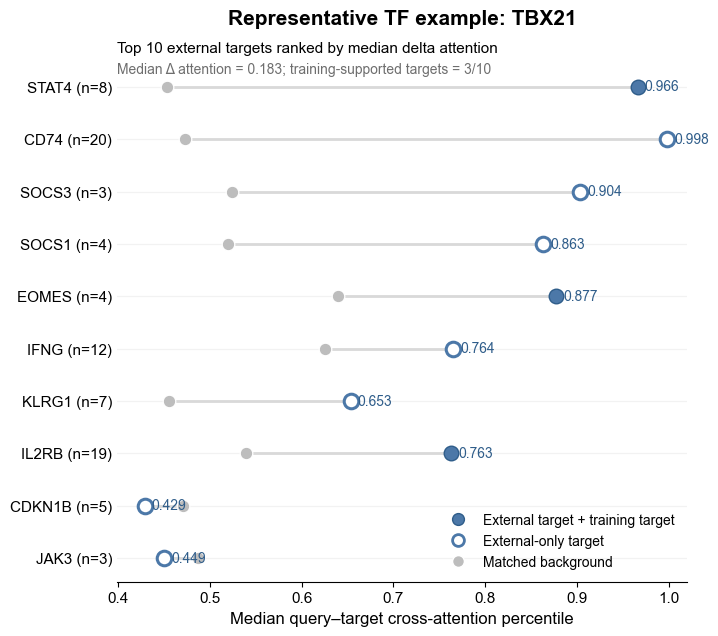

Saved to:
/root/autodl-tmp/fig5-1/geosketch_50_fig5d/tbx21/TBX21_external_target_dumbbell_blue.png
/root/autodl-tmp/fig5-1/geosketch_50_fig5d/tbx21/TBX21_external_target_dumbbell_blue.pdf
/root/autodl-tmp/fig5-1/geosketch_50_fig5d/tbx21/TBX21_external_target_dumbbell_blue.svg
/root/autodl-tmp/fig5-1/geosketch_50_fig5d/tbx21/TBX21_plot_data.csv


In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D

# =========================
# 1. 用户自己填写路径
# =========================
CSV_PATH = Path("/root/autodl-tmp/fig5-1/geosketch_50_fig5d/canonical_tf_external_target_gene_summary.csv")
OUT_DIR = Path("/root/autodl-tmp/fig5-1/geosketch_50_fig5d/tbx21")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2. 参数
# =========================
TF_NAME = "TBX21"
TOP_N = 10
MIN_N_CELLS = 3
SORT_BY = "median_delta_attention"   # 或 "median_attention_percentile"

# =========================
# 3. 蓝色配色
# =========================
BLUE = "#4C78A8"          # 主蓝
BLUE_DARK = "#2F5D8A"     # 深蓝
BLUE_LIGHT = "#9ECAE1"    # 浅蓝
GREY = "#BDBDBD"
GREY_DARK = "#6E6E6E"
LINE_GREY = "#D9D9D9"
GRID_GREY = "#F2F2F2"

# =========================
# 4. Arial 字体
# =========================
try:
    fm.findfont("Arial", fallback_to_default=False)
    FONT_FAMILY = "Arial"
except Exception:
    FONT_FAMILY = "sans-serif"

mpl.rcParams.update({
    "font.family": FONT_FAMILY,
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# =========================
# 5. 读数据
# =========================
df = pd.read_csv(CSV_PATH)

required_cols = [
    "tf_gene",
    "target_gene",
    "n_cells",
    "median_attention_percentile",
    "median_matched_background",
    "median_delta_attention",
    "fraction_also_training_target",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"CSV 缺少这些列: {missing}")

sub = df[df["tf_gene"] == TF_NAME].copy()

if len(sub) == 0:
    raise ValueError(f"没有找到 tf_gene == {TF_NAME} 的记录")

sub = sub[sub["n_cells"] >= MIN_N_CELLS].copy()

if len(sub) == 0:
    raise ValueError(f"{TF_NAME} 没有满足 n_cells >= {MIN_N_CELLS} 的基因")

sub = sub.sort_values(
    by=[SORT_BY, "median_attention_percentile"],
    ascending=[False, False]
).head(TOP_N).copy()

sub = sub.reset_index(drop=True)
sub["plot_label"] = sub["target_gene"] + " (n=" + sub["n_cells"].astype(int).astype(str) + ")"
sub["is_training_supported"] = sub["fraction_also_training_target"] > 0

# 为了让 top 在最上面
sub = sub.iloc[::-1].reset_index(drop=True)

# =========================
# 6. 坐标
# =========================
y = np.arange(len(sub))
x_target = sub["median_attention_percentile"].to_numpy(float)
x_bg = sub["median_matched_background"].to_numpy(float)

xmin = min(np.nanmin(x_target), np.nanmin(x_bg))
xmax = max(np.nanmax(x_target), np.nanmax(x_bg))

xpad_left = 0.03
xpad_right = 0.10
xlim_left = max(0.0, xmin - xpad_left)
xlim_right = min(1.02, xmax + xpad_right)

# =========================
# 7. 作图
# =========================
fig_h = max(5.2, 0.52 * len(sub) + 2.0)
fig, ax = plt.subplots(figsize=(7.6, fig_h))

# 背景横线
for yi in y:
    ax.axhline(yi, color=GRID_GREY, lw=0.9, zorder=0)

# 连接线
for yi, xt, xb in zip(y, x_target, x_bg):
    ax.plot([xb, xt], [yi, yi], color=LINE_GREY, lw=2.0, zorder=1)

# background 点
ax.scatter(
    x_bg, y,
    s=82,
    color=GREY,
    edgecolor="white",
    linewidth=0.9,
    zorder=2,
)

mask_train = sub["is_training_supported"].to_numpy(bool)
mask_external_only = ~mask_train

# training-supported: 实心蓝点
if mask_train.any():
    ax.scatter(
        x_target[mask_train], y[mask_train],
        s=110,
        facecolor=BLUE,
        edgecolor=BLUE_DARK,
        linewidth=1.0,
        zorder=3,
    )

# external-only: 空心蓝点
if mask_external_only.any():
    ax.scatter(
        x_target[mask_external_only], y[mask_external_only],
        s=110,
        facecolor="white",
        edgecolor=BLUE,
        linewidth=2.2,
        zorder=3,
    )

# 右侧数字
for yi, xt in zip(y, x_target):
    ax.text(
        xt + 0.008, yi,
        f"{xt:.3f}",
        va="center", ha="left",
        fontsize=10, color=BLUE_DARK
    )

# y 轴标签
ax.set_yticks(y)
ax.set_yticklabels(sub["plot_label"], fontsize=11)

# x 轴
ax.set_xlim(xlim_left, xlim_right)
ax.set_xlabel("Median query–target cross-attention percentile", fontsize=12)

# 主标题：只保留一行
ax.set_title(
    f"Representative TF example: {TF_NAME}",
    fontsize=15,
    fontweight="bold",
    pad=28
)

# 副标题/说明：放到图内左上角
n_show = len(sub)
n_training_supported = int(mask_train.sum())
median_delta = float(sub["median_delta_attention"].median())

ax.text(
    0.0, 1.015,
    f"Top {n_show} external targets ranked by {SORT_BY.replace('_', ' ')}",
    transform=ax.transAxes,
    ha="left", va="bottom",
    fontsize=11, color="black"
)

ax.text(
    0.0, 0.975,
    f"Median Δ attention = {median_delta:.3f}; training-supported targets = {n_training_supported}/{n_show}",
    transform=ax.transAxes,
    ha="left", va="bottom",
    fontsize=10, color=GREY_DARK
)

# 坐标轴样式
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", length=0)

# 图例
legend_handles = [
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=BLUE, markeredgecolor=BLUE_DARK,
           markersize=8.5, label="External target + training target"),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor="white", markeredgecolor=BLUE,
           markeredgewidth=2, markersize=8.5, label="External-only target"),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=GREY, markeredgecolor="white",
           markersize=8.5, label="Matched background"),
]

ax.legend(
    handles=legend_handles,
    loc="lower right",
    frameon=False,
    fontsize=10
)

# 布局：重点增加顶部空间
plt.subplots_adjust(top=0.84, left=0.22, right=0.97, bottom=0.12)

# 保存
out_prefix = OUT_DIR / f"{TF_NAME}_external_target_dumbbell_blue"
fig.savefig(str(out_prefix) + ".png", dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(str(out_prefix) + ".pdf", bbox_inches="tight", facecolor="white")
fig.savefig(str(out_prefix) + ".svg", bbox_inches="tight", facecolor="white")

plt.show()

# 同时导出作图数据
sub.iloc[::-1].to_csv(OUT_DIR / f"{TF_NAME}_plot_data.csv", index=False)

print("Saved to:")
print(str(out_prefix) + ".png")
print(str(out_prefix) + ".pdf")
print(str(out_prefix) + ".svg")
print(OUT_DIR / f"{TF_NAME}_plot_data.csv")

Evaluable TF × cell-type combinations: 787
TFs: 49
Cell types: 216

Selected TFs:
['NR2F1', 'GTF3A', 'KMT2A', 'ING4', 'TP73', 'LEF1', 'PPARA', 'RUNX1', 'GFI1', 'KLF4', 'SF1', 'AHR']

Selected cell types:
['memory B cell', 'macrophage', 'lymphocyte', 'native cell', 'leukocyte', 'plasmablast', 'CD8-positive, alpha-beta T cell', 'naive B cell', 'regulatory T cell', 'fibroblast', 'basal cell of prostate epithelium', 'classical monocyte']

Heatmap shape:
(12, 12)


cell_type_clean,memory B cell,macrophage,lymphocyte,native cell,leukocyte,plasmablast,"CD8-positive, alpha-beta T cell",naive B cell,regulatory T cell,fibroblast,basal cell of prostate epithelium,classical monocyte
tf_gene,,,,,,,,,,,,
NR2F1,-0.044198,-0.073150,-0.092876,-0.115205,-0.333679,-0.091007,-0.025110,-0.071648,-0.119881,-0.104119,-0.160752,-0.072308
GTF3A,0.087236,0.009008,0.125250,0.047009,0.062120,0.149631,0.168750,0.082535,0.104511,-0.012357,0.007056,0.076904
KMT2A,0.049703,0.066284,0.130607,0.009590,0.045407,0.095349,0.153498,0.098257,0.079949,-0.029727,0.088298,0.106977
ING4,0.052879,0.142877,0.260327,-0.042399,0.136890,0.038026,NaN,-0.021032,NaN,-0.116965,-0.049568,NaN
TP73,NaN,0.057479,NaN,NaN,0.191969,NaN,0.208371,NaN,0.215376,NaN,0.045310,0.045000
LEF1,NaN,0.083808,0.239938,0.154632,0.140149,NaN,0.200068,NaN,0.257303,0.164646,NaN,NaN
PPARA,0.174520,-0.082471,0.151799,0.131685,NaN,0.187721,0.104167,0.144039,NaN,NaN,NaN,-0.104894
RUNX1,0.161838,0.107295,0.188352,0.177744,0.069933,0.127233,0.184537,0.118885,0.198998,NaN,NaN,0.043596
GFI1,0.136743,NaN,-0.162852,NaN,-0.110032,NaN,-0.065771,NaN,0.081131,NaN,NaN,NaN


Color range: -0.250 ~ 0.250


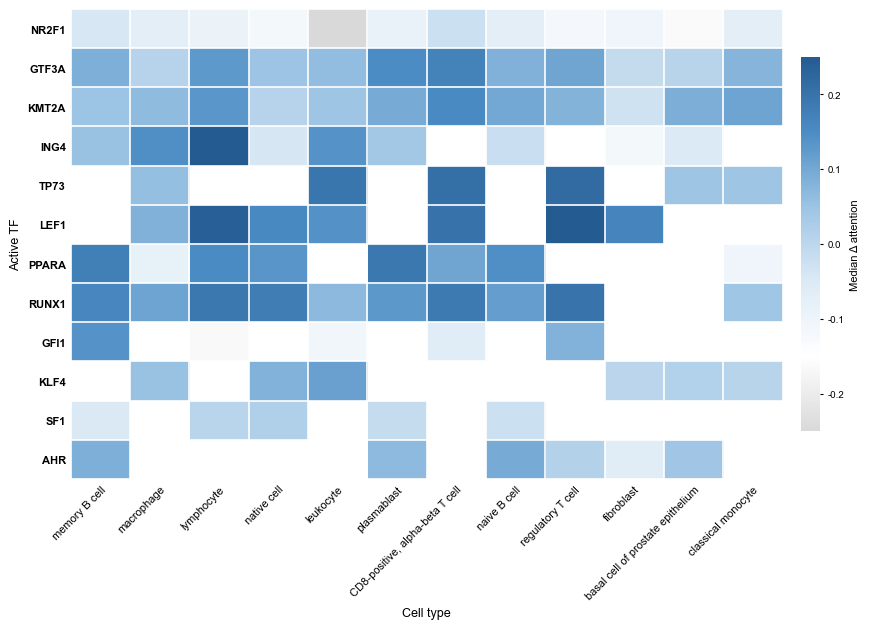


Saved:
/root/autodl-tmp/fig5-1/geosketch_50_fig5d/heatmap/Fig5e_TF_celltype_regulatory_retrieval_heatmap.png
/root/autodl-tmp/fig5-1/geosketch_50_fig5d/heatmap/Fig5e_TF_celltype_regulatory_retrieval_heatmap.pdf
/root/autodl-tmp/fig5-1/geosketch_50_fig5d/heatmap/Fig5e_TF_celltype_regulatory_retrieval_heatmap.svg


In [17]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


# ============================================================
# 1. USER CONFIG
# ============================================================

CSV_PATH = Path(
    "/root/autodl-tmp/fig5-1/geosketch_50_fig5d/cell_active_tf_attention_summary.csv"
)

OUT_DIR = Path(
    "/root/autodl-tmp/fig5-1/geosketch_50_fig5d/heatmap"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Plot parameters
# ============================================================

# 一个 TF × cell type 至少多少 evaluable cells 才画
MIN_CELLS_PER_TF_CELLTYPE = 3

# 最终显示多少 TF / cell types
TOP_N_TFS = 12
TOP_N_CELLTYPES = 12

# ------------------------------------------------------------
# TF 选择方式
#
# "coverage":
#   按能够评价的 cell-type 数量选择 TF
#   推荐正文使用，不根据效果值挑 TF
#
# "canonical":
#   使用你提前规定好的 TF
# ------------------------------------------------------------

TF_SELECTION_MODE = "coverage"

CANONICAL_TFS = [
    "PAX5",
    "EBF1",
    "SPI1",
    "IRF8",
    "TBX21",
    "EOMES",
    "STAT1",
    "STAT3",
    "RELA",
    "MYC",
]

# 是否在 heatmap 上叠加 coverage circle
# circle 越大 = 该 TF × cell type evaluable cells 越多
SHOW_COVERAGE_DOTS = False


# ============================================================
# 3. Font
# ============================================================

try:
    fm.findfont(
        "Arial",
        fallback_to_default=False,
    )
    FONT_FAMILY = "Arial"
except Exception:
    FONT_FAMILY = "sans-serif"

mpl.rcParams.update({
    "font.family": FONT_FAMILY,
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


# ============================================================
# 4. Read data
# ============================================================

df = pd.read_csv(CSV_PATH)

required = [
    "cell_type",
    "tf_gene",
    "cell_id",
    "delta_attention",
]

missing = [
    c
    for c in required
    if c not in df.columns
]

if missing:
    raise ValueError(
        f"CSV 缺少字段: {missing}"
    )

df = df.dropna(
    subset=[
        "cell_type",
        "tf_gene",
        "delta_attention",
    ]
).copy()


# ============================================================
# 5. Clean cell-type labels
# ============================================================

def clean_celltype(x):
    x = str(x).strip()

    # 去掉下划线
    x = x.replace("_", " ")

    # / 换成自然空格
    x = x.replace("/", " ")

    # 多余空格压缩
    x = " ".join(x.split())

    return x


df["cell_type_clean"] = (
    df["cell_type"]
    .map(clean_celltype)
)


# ============================================================
# 6. Aggregate:
#    TF × cell type
# ============================================================

agg = (
    df
    .groupby(
        [
            "tf_gene",
            "cell_type_clean",
        ],
        as_index=False,
    )
    .agg(
        median_delta_attention=(
            "delta_attention",
            "median",
        ),
        n_cells=(
            "cell_id",
            "nunique",
        ),
        median_target_attention=(
            "target_attention",
            "median",
        ),
        median_background_attention=(
            "background_attention",
            "median",
        ),
    )
)

# 组合层面 QC
agg = agg[
    agg["n_cells"]
    >= MIN_CELLS_PER_TF_CELLTYPE
].copy()

print(
    "Evaluable TF × cell-type combinations:",
    len(agg),
)

print(
    "TFs:",
    agg["tf_gene"].nunique(),
)

print(
    "Cell types:",
    agg["cell_type_clean"].nunique(),
)


# ============================================================
# 7. Select TFs
#    不按 delta_attention 选择
# ============================================================

tf_coverage = (
    agg
    .groupby("tf_gene")
    .agg(
        n_cell_types=(
            "cell_type_clean",
            "nunique",
        ),
        n_cells=(
            "n_cells",
            "sum",
        ),
    )
    .sort_values(
        [
            "n_cell_types",
            "n_cells",
        ],
        ascending=False,
    )
)


if TF_SELECTION_MODE == "canonical":

    available_tfs = set(
        agg["tf_gene"]
    )

    selected_tfs = [
        tf
        for tf in CANONICAL_TFS
        if tf in available_tfs
    ][:TOP_N_TFS]

else:

    selected_tfs = (
        tf_coverage
        .head(TOP_N_TFS)
        .index
        .tolist()
    )


print("\nSelected TFs:")
print(selected_tfs)


# ============================================================
# 8. Select cell types
#    同样按 coverage，而不是 effect
# ============================================================

tmp = agg[
    agg["tf_gene"].isin(
        selected_tfs
    )
].copy()

celltype_coverage = (
    tmp
    .groupby("cell_type_clean")
    .agg(
        n_tfs=(
            "tf_gene",
            "nunique",
        ),
        n_cells=(
            "n_cells",
            "sum",
        ),
    )
    .sort_values(
        [
            "n_tfs",
            "n_cells",
        ],
        ascending=False,
    )
)

selected_celltypes = (
    celltype_coverage
    .head(TOP_N_CELLTYPES)
    .index
    .tolist()
)

print("\nSelected cell types:")
print(selected_celltypes)


# ============================================================
# 9. Final matrix
# ============================================================

plot_df = agg[
    agg["tf_gene"].isin(
        selected_tfs
    )
    &
    agg["cell_type_clean"].isin(
        selected_celltypes
    )
].copy()


value_matrix = (
    plot_df
    .pivot(
        index="tf_gene",
        columns="cell_type_clean",
        values="median_delta_attention",
    )
    .reindex(
        index=selected_tfs,
        columns=selected_celltypes,
    )
)


coverage_matrix = (
    plot_df
    .pivot(
        index="tf_gene",
        columns="cell_type_clean",
        values="n_cells",
    )
    .reindex(
        index=selected_tfs,
        columns=selected_celltypes,
    )
)


# ============================================================
# 10. Optional ordering
#
# 当前保持 coverage order。
#
# 如果后面你想聚类，我再单独给你 hierarchical clustering 版本。
# ============================================================

print("\nHeatmap shape:")
print(value_matrix.shape)

display(value_matrix)


# ============================================================
# 11. Blue colormap
#
# negative -> light gray
# 0        -> white
# positive -> blue
# ============================================================

cmap = LinearSegmentedColormap.from_list(
    "regulatory_blue",
    [
        "#D9D9D9",   # negative
        "#FFFFFF",   # zero
        "#DCEAF5",
        "#9CC4E4",
        "#4C8CC4",
        "#245B91",   # strong positive
    ],
    N=256,
)

# NaN = white
cmap.set_bad(
    color="#FFFFFF"
)


# ============================================================
# 12. Color scale
#
# 对称于 0，避免正负值视觉不公平
# ============================================================

vals = value_matrix.to_numpy(
    dtype=float
)

finite = vals[
    np.isfinite(vals)
]

if len(finite) == 0:
    raise RuntimeError(
        "Heatmap 没有有效值"
    )

# 用 97.5 percentile 防止极端值把颜色范围拉爆
abs_lim = np.nanpercentile(
    np.abs(finite),
    97.5,
)

abs_lim = max(
    abs_lim,
    0.05,
)

norm = TwoSlopeNorm(
    vmin=-abs_lim,
    vcenter=0,
    vmax=abs_lim,
)

print(
    f"Color range: {-abs_lim:.3f} ~ {abs_lim:.3f}"
)


# ============================================================
# 13. Plot
# ============================================================

n_rows, n_cols = (
    value_matrix.shape
)

fig_w = max(
    6.0,
    n_cols * 0.55 + 2.2,
)

fig_h = max(
    4.0,
    n_rows * 0.40 + 1.6,
)

fig, ax = plt.subplots(
    figsize=(
        fig_w,
        fig_h,
    )
)


masked_values = np.ma.masked_invalid(
    vals
)

im = ax.imshow(
    masked_values,
    cmap=cmap,
    norm=norm,
    aspect="auto",
    interpolation="nearest",
)


# ============================================================
# 14. Optional coverage dots
# ============================================================

if SHOW_COVERAGE_DOTS:

    cov = coverage_matrix.to_numpy(
        dtype=float
    )

    finite_cov = cov[
        np.isfinite(cov)
    ]

    if len(finite_cov):

        max_cov = np.nanpercentile(
            finite_cov,
            95,
        )

        max_cov = max(
            max_cov,
            1,
        )

        for i in range(
            n_rows
        ):
            for j in range(
                n_cols
            ):

                if (
                    not np.isfinite(
                        vals[i, j]
                    )
                    or
                    not np.isfinite(
                        cov[i, j]
                    )
                ):
                    continue

                size = (
                    6
                    +
                    26
                    *
                    np.sqrt(
                        min(
                            cov[i, j]
                            / max_cov,
                            1,
                        )
                    )
                )

                ax.scatter(
                    j,
                    i,
                    s=size,
                    facecolor="none",
                    edgecolor="#2F5D8A",
                    linewidth=0.55,
                    alpha=0.70,
                    zorder=3,
                )


# ============================================================
# 15. Axis labels
# ============================================================

ax.set_xticks(
    np.arange(
        n_cols
    )
)

ax.set_xticklabels(
    value_matrix.columns,
    rotation=45,
    ha="right",
    rotation_mode="anchor",
    fontsize=8,
)

ax.set_yticks(
    np.arange(
        n_rows
    )
)

ax.set_yticklabels(
    value_matrix.index,
    fontsize=8,
    fontweight="bold",
)


# ============================================================
# 16. Cell borders
# ============================================================

ax.set_xticks(
    np.arange(
        -0.5,
        n_cols,
        1,
    ),
    minor=True,
)

ax.set_yticks(
    np.arange(
        -0.5,
        n_rows,
        1,
    ),
    minor=True,
)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=1.2,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)


# ============================================================
# 17. Clean frame
# ============================================================

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis="both",
    length=0,
)


# ============================================================
# 18. Labels
# ============================================================

ax.set_xlabel(
    "Cell type",
    fontsize=9,
)

ax.set_ylabel(
    "Active TF",
    fontsize=9,
)


# 正文拼图建议不要标题
# 如果想单独看图，可以取消下面两行注释

# ax.set_title(
#     "Context-specific regulatory target retrieval",
#     fontsize=9,
#     fontweight="bold",
#     pad=8,
# )


# ============================================================
# 19. Colorbar
# ============================================================

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.025,
    pad=0.025,
)

cbar.set_label(
    "Median Δ attention",
    fontsize=8,
)

cbar.ax.tick_params(
    labelsize=7,
    length=2,
)

cbar.outline.set_visible(
    False
)


# ============================================================
# 20. Layout
# ============================================================

plt.tight_layout()


# ============================================================
# 21. Save
# ============================================================

prefix = (
    OUT_DIR
    /
    "Fig5e_TF_celltype_regulatory_retrieval_heatmap"
)

fig.savefig(
    str(prefix) + ".png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    str(prefix) + ".pdf",
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    str(prefix) + ".svg",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ============================================================
# 22. Export plotting data
# ============================================================

value_matrix.to_csv(
    OUT_DIR
    /
    "Fig5e_heatmap_delta_attention_matrix.csv"
)

coverage_matrix.to_csv(
    OUT_DIR
    /
    "Fig5e_heatmap_n_cells_matrix.csv"
)

plot_df.to_csv(
    OUT_DIR
    /
    "Fig5e_heatmap_long_format.csv",
    index=False,
)

print("\nSaved:")
print(str(prefix) + ".png")
print(str(prefix) + ".pdf")
print(str(prefix) + ".svg")


## Main outputs

- `cell_active_tf_attention_summary.csv` — one row per evaluable `cell × active TF`
- `external_target_gene_level.parquet` — external target-level details
- `tf_level_attention_summary.csv` — final TF-level table
- `main_statistics.csv`
- `fig5d_active_regulon_external_target_attention.pdf/svg/png`
- `canonical_tf_summary.csv`
- `canonical_tf_external_target_gene_summary.csv`
- `training_regulon_collectri_overlap_qc.csv`

### Interpretation if positive

If external CollecTRI targets have higher query-TF cross-attention than expression/detection-matched non-targets across TFs, the result supports:

> During decoding of cell-active regulatory programs, the Regulon Decoder preferentially retrieved encoder genes supported as targets of the queried TF by an independent regulatory resource.

A conservative knowledge-injection statement is:

> Regulatory information introduced during Stage2 training was accessible from encoder representations through the Regulon Decoder.

Do **not** describe VAL as an independent test set, and do **not** claim that scKODE reconstructed the true GRN.
